## Data Prepration

In [79]:
import pandas as pd
import numpy as np

data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [80]:
!curl -o data.csv $data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  620k  100  620k    0     0  1128k      0 --:--:-- --:--:-- --:--:-- 1127k


In [113]:
df = pd.read_csv('data.csv')

In [114]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [115]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [116]:
# df.columns = df.columns.str.lower().str.replace(' ', '_')

In [117]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [118]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_').str.replace('-', '_')

In [119]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front_wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front_wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front_wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front_wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front_wheel_drive,3,2580,7,304.0,4510,17.5,31.0


## EDA (Exploratory data analysis)

In [120]:
print(len(df))
print()

for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

10000

model_year
[2006 2008 1996 1989 1994]
50

origin
<StringArray>
['europe', 'asia', 'usa']
Length: 3, dtype: str
3

fuel_type
<StringArray>
['gasoline', 'diesel', 'hybrid']
Length: 3, dtype: str
3

drivetrain
<StringArray>
['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive']
Length: 3, dtype: str
3

num_doors
[4 5 3 2]
4

engine_displacement
[2180 2390 2320 2130 2580]
127

num_cylinders
[6 7 5 8 4]
5

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

acceleration
[ nan 17.3 18.7 17.5 18.8]
93

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

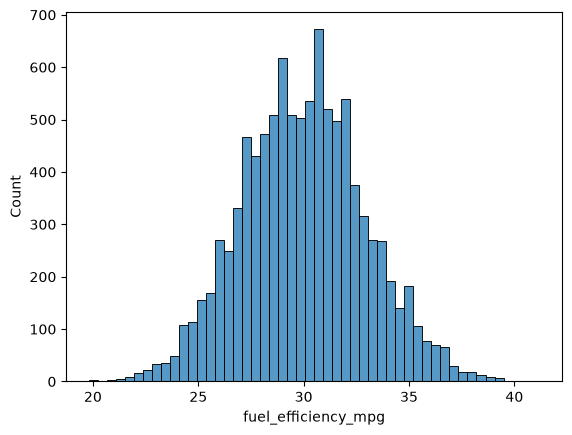

In [122]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

# sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg < 100000], bins=50)

In [123]:
# if data very big or skewed can use log

fuel_efficience_mpg_logs = np.log1p(df.fuel_efficiency_mpg)


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

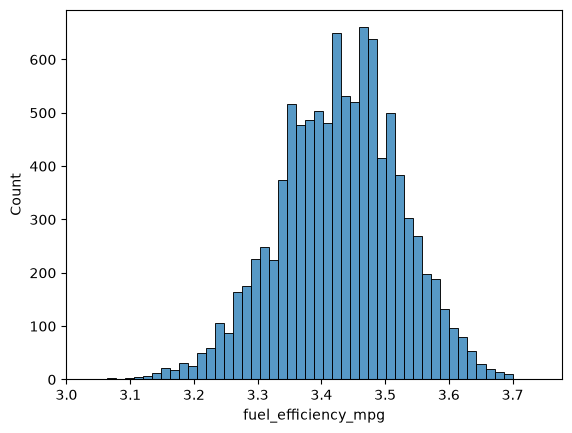

In [124]:
sns.histplot(fuel_efficience_mpg_logs, bins=50)

In [125]:
df.isnull().sum().values > 0

array([False, False, False, False, False, False, False,  True, False,
        True, False])

In [126]:
df.columns[df.isnull().sum().values > 0]

Index(['horsepower', 'acceleration'], dtype='str')

## Setting up validation framework

In [127]:
n = len(df)

n_val = int(len(df) * 0.2)
n_test = int(len(df) * 0.2)
n_train = n - n_val - n_test

print(n_val, n_test, n_train)

2000 2000 6000


In [128]:
idx = np.arange(n)

np.random.seed(2)
np.random.shuffle(idx)

In [129]:
# df_val = df.iloc[ : n_val]
# df_test = df.iloc[n_val + 1 : n_val + n_test]
# df_train = df.iloc[n_val + n_test + 1 : ]

#df_train = df[n_val + n_test + 1 : ] -> Only take labels, not the rows.


In [130]:
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train : n_train + n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [131]:
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

In [132]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Linear Regression